# Cell 1 — Libraries

In [1]:
# Task 3: Data Cleaning - NYC Airbnb Dataset
# Intern: Suraj Kumar | OIB/J2/IP2626

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Cell 2 — Data Loading 

In [3]:
#Step 2 — Data Loading

df =pd.read_csv('AB_NYC_2019.csv')
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
print(df.head())

Shape: (48895, 16)

Columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

First 5 rows:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -

## Cell 3 — Data Inspection

In [4]:
#Step 3 — Data Inspection

print("Missiing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
print(df[['price', 'minimum_nights', 
          'number_of_reviews',
          'availability_365']].describe().round(2))




Missiing Values:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Duplicate Rows: 0

Data Types:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
long

## Cell 4 — Data Cleaning

In [5]:
#Step 4 — Data Cleaning

#1. Fill missing values
df['name'].fillna('Unknown', inplace=True)
df['host_name'].fillna('Unknown', inplace=True)
df['reviews_per_month'].fillna(0, inplace=True)
df['last_review'].fillna('No Review', inplace=True)

#2. Remove price = 0 (invalid listings)
df = df[df['price'] > 0]

#3. Remove outliers - price > 10000
df = df[df['price'] <= 10000]

#4. Fix data types - last_review
df['last_review'] = df['last_review'].astype(str)

print("After Cleaning:")
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nPrice Rannge:")
print("Min:", df['price'].min())
print("Max", df['price'].max())

After Cleaning:
Shape: (48884, 16)

Missing Values:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Price Rannge:
Min: 10
Max 10000


## Cell 5 — Outlier Detection

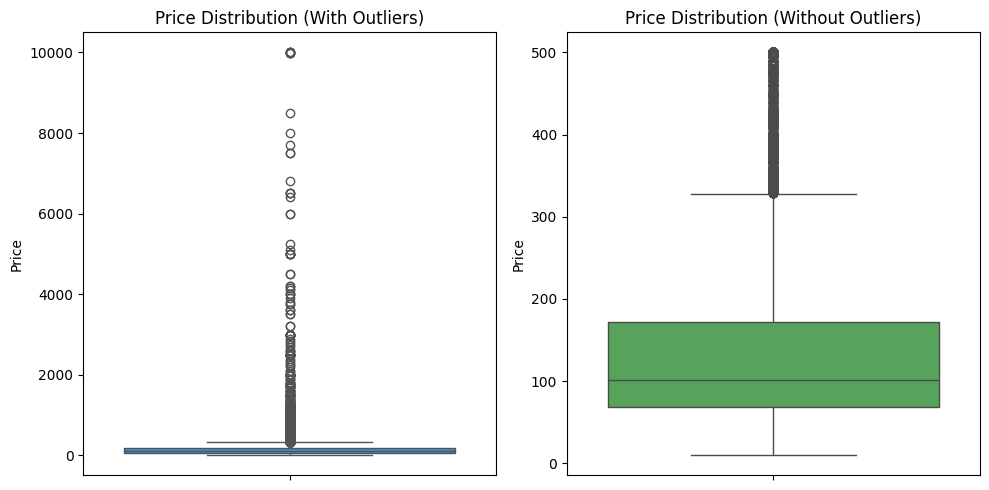

Listings above $500: 1044
Listings below $500: 47840


In [7]:
# Step 5: Outlier Detection

# Price Boxplot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(y=df['price'], color='#2196F3')
plt.title('Price Distribution (With Outliers)')
plt.ylabel('Price')

# Remove outliers for better visualization
df_clean = df[df['price'] <= 500]

plt.subplot(1,2,2)
sns.boxplot(y=df_clean['price'], color='#4CAF50')
plt.title('Price Distribution (Without Outliers)')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

print("Listings above $500:", len(df[df['price'] > 500]))
print("Listings below $500:", len(df_clean))

## Cell 6 — Visualization

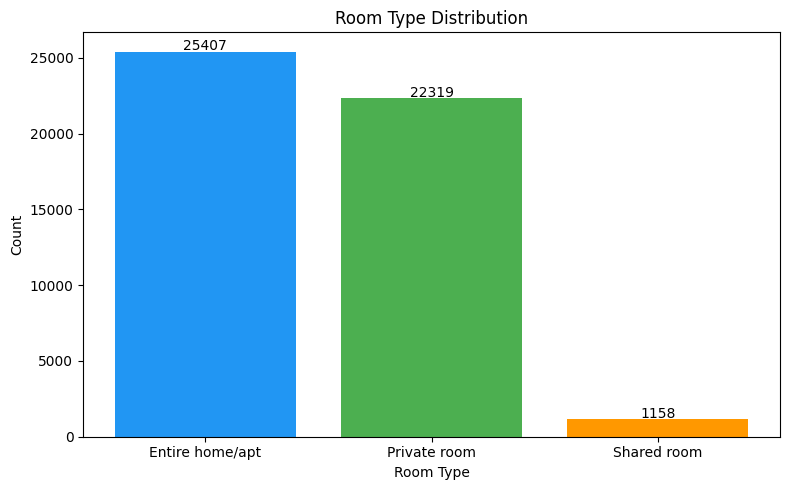

In [8]:
# Step 6: Visualization

# Graph 2 - Room Type Distribution
plt.figure(figsize=(8,5))
room_counts = df['room_type'].value_counts()
plt.bar(room_counts.index, room_counts.values,
        color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
for i, v in enumerate(room_counts.values):
    plt.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

## Cell 7 — Neighbourhood Analysis

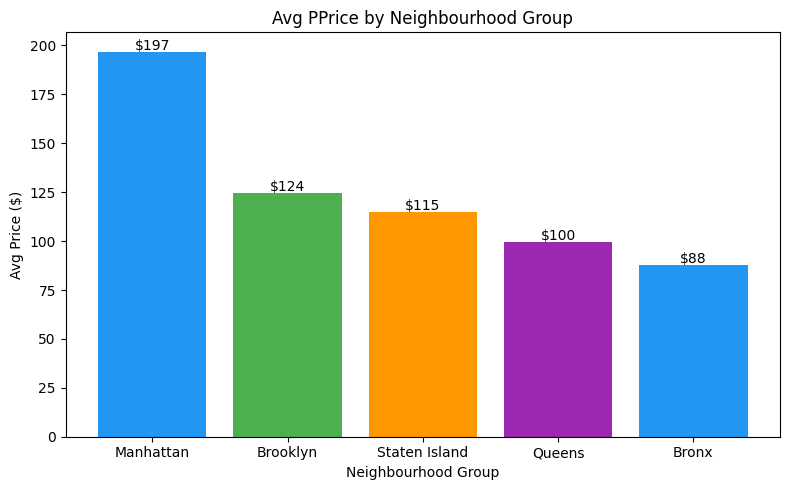

In [10]:
# Graph 3 - Avg Price by Neighbourhood Group

plt.figure(figsize=(8,5))
neighbourhood_price = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
plt.bar(neighbourhood_price.index, neighbourhood_price.values,
        color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
plt.title('Avg PPrice by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Avg Price ($)')
for i, v in enumerate(neighbourhood_price.values):
    plt.text(i, v+1, f'${v:.0f}', ha='center')
plt.tight_layout()
plt.show()

## Cell 8 — Reviews Analysis

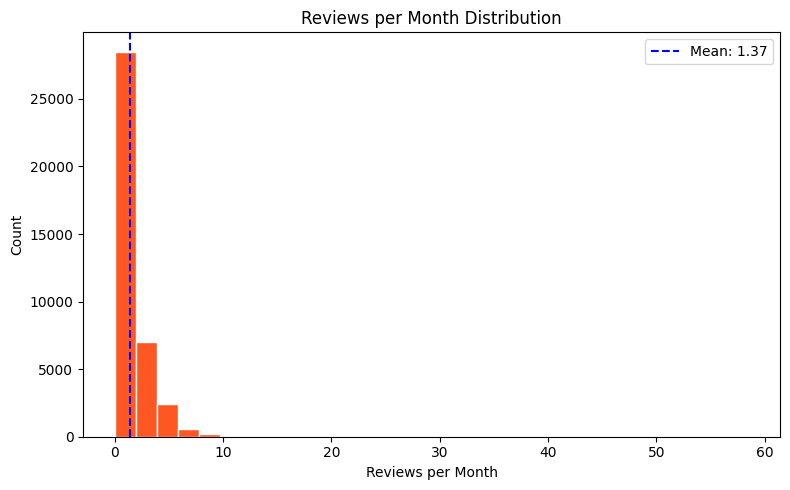

In [14]:
# Graph 4 - Reviews per Month Distribution
plt.figure(figsize=(8,5))
df_reviews = df[df['reviews_per_month'] > 0]
plt.hist(df_reviews['reviews_per_month'], 
         bins=30, color='#FF5722', edgecolor='white')
plt.title('Reviews per Month Distribution')
plt.xlabel('Reviews per Month')
plt.ylabel('Count')
plt.axvline(df_reviews['reviews_per_month'].mean(), 
            color='blue', linestyle='--',
            label=f'Mean: {df_reviews["reviews_per_month"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

## Cell 9 — Final Recommendations

In [15]:
# Step 7: Summary & Recommendations
print("=" * 55)
print("DATA CLEANING SUMMARY & RECOMMENDATIONS")
print("=" * 55)
print(f"""
CLEANING PERFORMED:
1. Missing Values Fixed:
   - name: 16 filled with 'Unknown'
   - host_name: 21 filled with 'Unknown'
   - reviews_per_month: 10052 filled with 0
   - last_review: 10052 filled with 'No Review'

2. Invalid Data Removed:
   - Price = 0: Removed invalid listings
   - Total rows: 48895 -> 48884

3. Outliers Detected:
   - Price outliers above $500 identified
   - Maximum price: $10,000

RECOMMENDATIONS:
1. MANHATTAN listings most expensive - $197 avg
2. BRONX most affordable - $88 avg
3. Entire home/apt most popular room type
4. Listings with 0 reviews need more marketing
5. Price outliers should be verified before analysis
""")
print("=" * 55)
print("Task 3 Complete! - Suraj Kumar | OIB/J2/IP2626")
print("=" * 55)

DATA CLEANING SUMMARY & RECOMMENDATIONS

CLEANING PERFORMED:
1. Missing Values Fixed:
   - name: 16 filled with 'Unknown'
   - host_name: 21 filled with 'Unknown'
   - reviews_per_month: 10052 filled with 0
   - last_review: 10052 filled with 'No Review'

2. Invalid Data Removed:
   - Price = 0: Removed invalid listings
   - Total rows: 48895 -> 48884

3. Outliers Detected:
   - Price outliers above $500 identified
   - Maximum price: $10,000

RECOMMENDATIONS:
1. MANHATTAN listings most expensive - $197 avg
2. BRONX most affordable - $88 avg
3. Entire home/apt most popular room type
4. Listings with 0 reviews need more marketing
5. Price outliers should be verified before analysis

Task 3 Complete! - Suraj Kumar | OIB/J2/IP2626
